# ***`Import Libraries`***

In [36]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

# ***`Data Loading and Initial Inspection`***

Reading and displaying data:

In [37]:
!gdown --id 1-Zyp-JP3f9QhPKaErBkPPFNKaPS1v74u

'gdown' is not recognized as an internal or external command,
operable program or batch file.


In [38]:
student = pd.read_csv(r'C:\Users\Syndictech\Downloads\AI model (2)\BAHAAW\AXI_Training\xAPI-Edu-Data.csv')

df = student.copy()
df.head(15)


,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,Under-7,M
1,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,Under-7,M
2,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,Above-7,L
3,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,Above-7,L
4,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,Above-7,M
5,F,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,42,30,13,70,Yes,Bad,Above-7,M
6,M,KW,KuwaIT,MiddleSchool,G-07,A,Math,F,Father,35,12,0,17,No,Bad,Above-7,L
7,M,KW,KuwaIT,MiddleSchool,G-07,A,Math,F,Father,50,10,15,22,Yes,Good,Under-7,M
8,F,KW,KuwaIT,MiddleSchool,G-07,A,Math,F,Father,12,21,16,50,Yes,Good,Under-7,M
9,F,KW,KuwaIT,MiddleSchool,G-07,B,IT,F,Father,70,80,25,70,Yes,Good,Under-7,M


In [39]:
print(df.shape)

(480, 17)


In [40]:
df.describe()

,raisedhands,VisITedResources,AnnouncementsView,Discussion
count,480.000000,480.000000,480.000000,480.000000
mean,46.775000,54.797917,37.918750,43.283333
std,30.779223,33.080007,26.611244,27.637735
min,0.000000,0.000000,0.000000,1.000000
25%,15.750000,20.000000,14.000000,20.000000
50%,50.000000,65.000000,33.000000,39.000000
75%,75.000000,84.000000,58.000000,70.000000
max,100.000000,99.000000,98.000000,99.000000


In [41]:
df.isnull().sum()

gender                      0
NationalITy                 0
PlaceofBirth                0
StageID                     0
GradeID                     0
SectionID                   0
Topic                       0
Semester                    0
Relation                    0
raisedhands                 0
VisITedResources            0
AnnouncementsView           0
Discussion                  0
ParentAnsweringSurvey       0
ParentschoolSatisfaction    0
StudentAbsenceDays          0
Class                       0
dtype: int64

In [42]:
df.dtypes

gender                      object
NationalITy                 object
PlaceofBirth                object
StageID                     object
GradeID                     object
SectionID                   object
Topic                       object
Semester                    object
Relation                    object
raisedhands                  int64
VisITedResources             int64
AnnouncementsView            int64
Discussion                   int64
ParentAnsweringSurvey       object
ParentschoolSatisfaction    object
StudentAbsenceDays          object
Class                       object
dtype: object

# ***`Select Features`***

In [43]:
features_to_keep = [
    'raisedhands', 'VisITedResources', 'AnnouncementsView', 'Discussion', # سلوكي رقمي
    'StudentAbsenceDays', 'ParentschoolSatisfaction', # سلوكي نصي
    'Class' # العمود الهدف
]


In [44]:
df= df[features_to_keep].copy()
df.head()

,raisedhands,VisITedResources,AnnouncementsView,Discussion,StudentAbsenceDays,ParentschoolSatisfaction,Class
0,15,16,2,20,Under-7,Good,M
1,20,20,3,25,Under-7,Good,M
2,10,7,0,30,Above-7,Bad,L
3,30,25,5,35,Above-7,Bad,L
4,40,50,12,50,Above-7,Bad,M


# ***`Exploratory Data Analysis (EDA)`***

Class
M    211
H    142
L    127
Name: count, dtype: int64



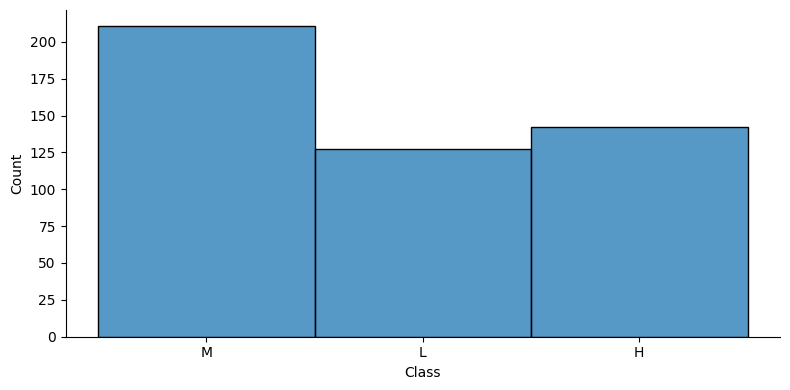

In [45]:
print(df['Class'].value_counts())
print()
sns.displot(data=df,x='Class',height=4,aspect=2)

,count,mean,std,min,25%,50%,75%,max,missing
raisedhands,480.0,46.775000,30.779223,0.0,15.75,50.0,75.0,100.0,0
VisITedResources,480.0,54.797917,33.080007,0.0,20.00,65.0,84.0,99.0,0
AnnouncementsView,480.0,37.918750,26.611244,0.0,14.00,33.0,58.0,98.0,0
Discussion,480.0,43.283333,27.637735,1.0,20.00,39.0,70.0,99.0,0


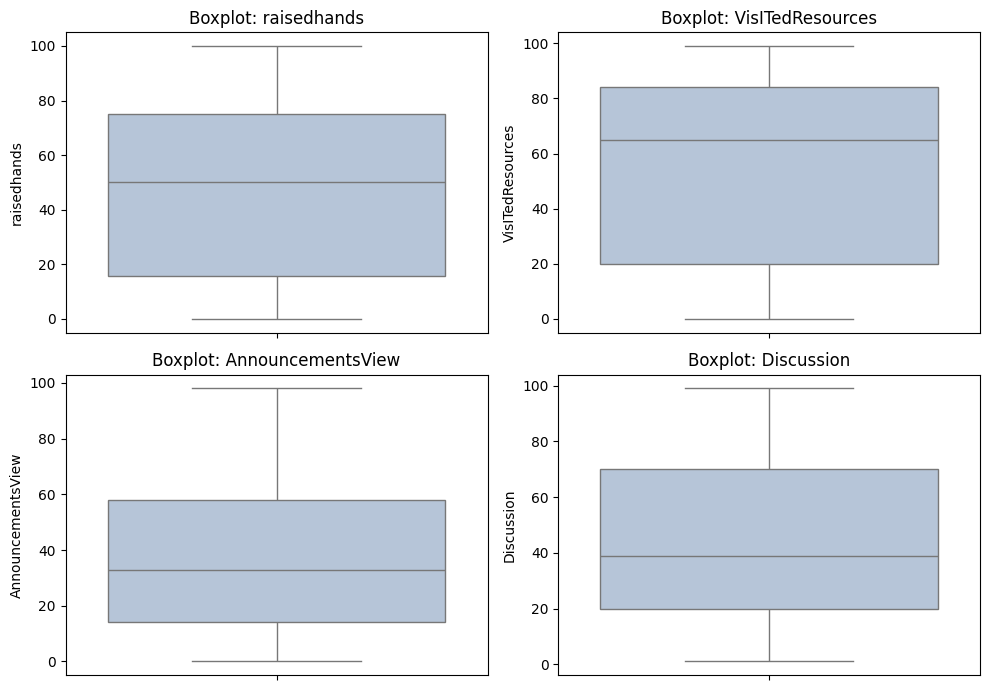

In [46]:
# Define numerical columns
num_cols = ['raisedhands', 'VisITedResources', 'AnnouncementsView', 'Discussion']

# إحصاءات أساسية
display(df[num_cols].describe().T.assign(missing=df[num_cols].isna().sum()))

# صندوقيات Boxplots للفصل بين القيم الطرفية
fig, axes = plt.subplots(2, 2, figsize=(10,7))
for ax, c in zip(axes.ravel(), num_cols):
    sns.boxplot(data=df, y=c, color="lightsteelblue", ax=ax)
    ax.set_title(f"Boxplot: {c}")
plt.tight_layout(); plt.show()

In [47]:
class_order = ["L","M","H"]
df['Class'] = pd.Categorical(df['Class'], categories=class_order, ordered=True)

C:\Users\Syndictech\AppData\Local\Temp\ipykernel_10088\3703535395.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  absence_counts = df.groupby('Class')['StudentAbsenceDays'].value_counts().unstack(fill_value=0)


StudentAbsenceDays,Above-7,Under-7
Class,,
L,116,11
M,71,140
H,4,138


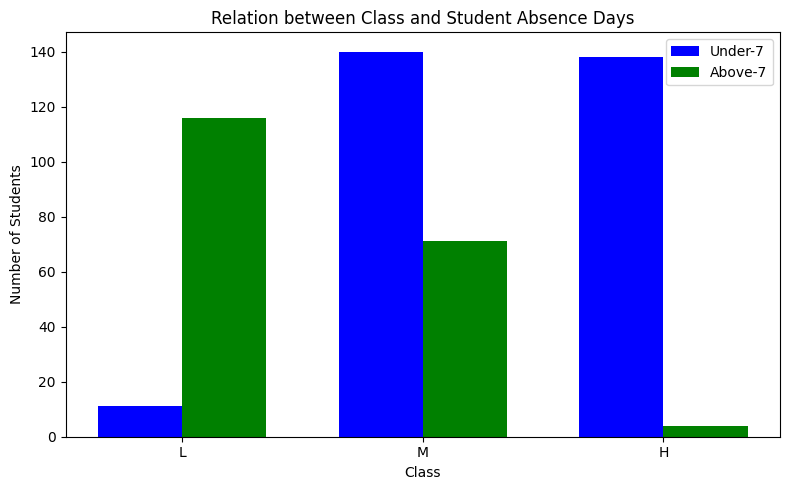

In [48]:
# Calculate counts of StudentAbsenceDays for each Class category
absence_counts = df.groupby('Class')['StudentAbsenceDays'].value_counts().unstack(fill_value=0)
display(absence_counts)

# Define the labels and positions for the x-axis
class_labels = absence_counts.index
index = np.arange(len(class_labels))
bar_width = 0.35

# Create the bar plot
plt.figure(figsize=(8, 5))
plt.bar(index, absence_counts["Under-7"], bar_width, label="Under-7", color="blue")
plt.bar(index + bar_width, absence_counts["Above-7"], bar_width, label="Above-7", color="green")

plt.title("Relation between Class and Student Absence Days")
plt.xlabel("Class")
plt.ylabel("Number of Students")
plt.xticks(index + bar_width / 2, class_labels)
plt.legend()
plt.tight_layout()
plt.show()

Class,L,M,H
raisedhands,,,
"(-0.001, 15.75]",69.2,24.2,6.7
"(15.75, 50.0]",26.9,60.4,12.7
"(50.0, 75.0]",6.4,50.9,42.7
"(75.0, 100.0]",0.9,38.8,60.3


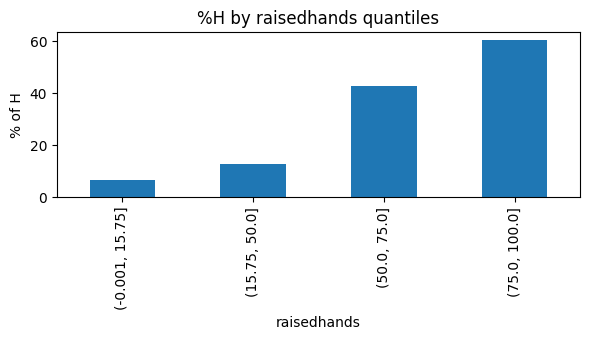

Class,L,M,H
VisITedResources,,,
"(-0.001, 20.0]",71.1,25.0,3.9
"(20.0, 65.0]",27.2,53.5,19.3
"(65.0, 84.0]",3.3,57.5,39.2
"(84.0, 99.0]",0.8,41.5,57.6


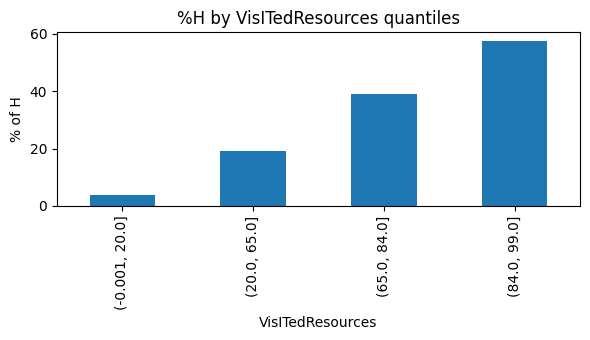

Class,L,M,H
AnnouncementsView,,,
"(-0.001, 14.0]",66.1,27.3,6.6
"(14.0, 33.0]",25.2,52.8,22.0
"(33.0, 58.0]",10.0,50.0,40.0
"(58.0, 98.0]",3.4,45.7,50.9


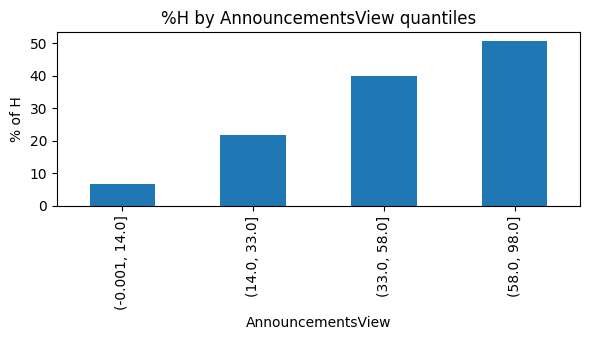

Class,L,M,H
Discussion,,,
"(0.999, 20.0]",48.1,37.2,14.7
"(20.0, 39.0]",19.6,50.0,30.4
"(39.0, 70.0]",23.7,47.5,28.8
"(70.0, 99.0]",10.0,41.0,49.0


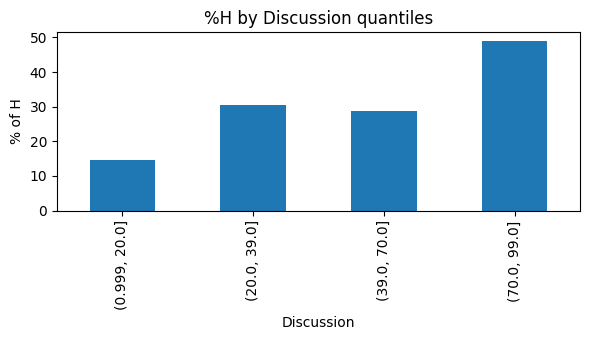

In [49]:
def lift_plot(feature, q=4):
    bins = pd.qcut(df[feature], q=q, duplicates="drop")
    tab = pd.crosstab(bins, df[target_col], normalize="index")*100
    display(tab.round(1))
    ax = tab["H"].plot(kind="bar", figsize=(6,3.5), title=f"%H by {feature} quantiles")
    ax.set_ylabel("% of H"); ax.set_xlabel(feature)
    plt.tight_layout(); plt.show()

target_col = 'Class'
for c in num_cols:
    lift_plot(c, q=4)

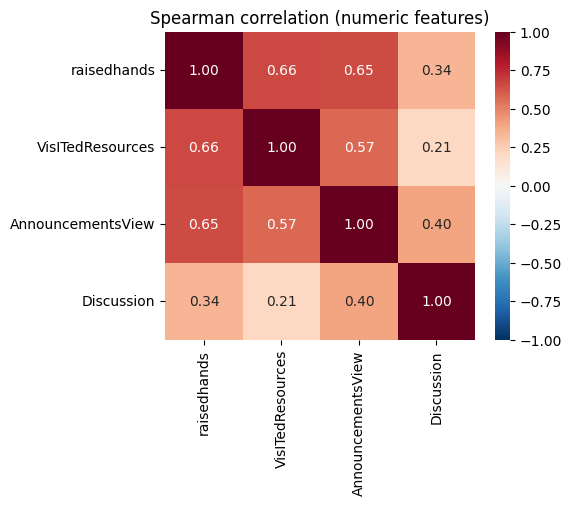

In [50]:
# Spearman مناسب للعدّ والرتب
corr = df[num_cols].corr(method="spearman")

plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1)
plt.title("Spearman correlation (numeric features)")
plt.show()

C:\Users\Syndictech\AppData\Local\Temp\ipykernel_10088\289101156.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  satisfaction_counts = df.groupby('Class')['ParentschoolSatisfaction'].value_counts().unstack(fill_value=0)


ParentschoolSatisfaction,Bad,Good
Class,,
L,84,43
M,80,131
H,24,118


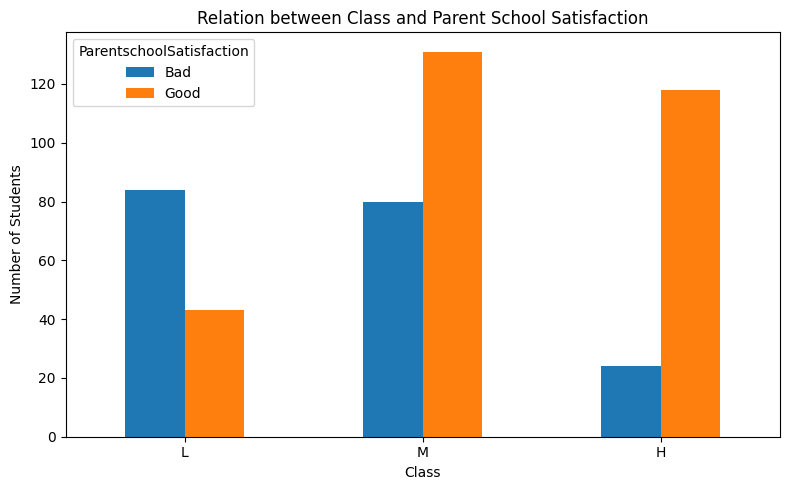

In [51]:

satisfaction_counts = df.groupby('Class')['ParentschoolSatisfaction'].value_counts().unstack(fill_value=0)
display(satisfaction_counts)

# Create the bar plot
satisfaction_counts.plot(kind='bar', figsize=(8, 5))

plt.title("Relation between Class and Parent School Satisfaction")
plt.xlabel("Class")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.legend(title="ParentschoolSatisfaction")
plt.tight_layout()
plt.show()

# ***`Encoding `***

In [52]:
# ***`Binary Encoding (no one-hot for binary)`***
num_cols = ['raisedhands','VisITedResources','AnnouncementsView','Discussion']


# 1 = Above-7, 0 = Under-7
df['absence_gt7'] = (df['StudentAbsenceDays'].astype(str).str.strip().eq('Above-7')).astype(int)
# 1 = Good, 0 = Bad
df['satisfaction_good'] = (df['ParentschoolSatisfaction'].astype(str).str.strip().eq('Good')).astype(int)


# إسقاط الأعمدة النصية الأصلية بعد إنشاء الثنائيات
df.drop(columns=['StudentAbsenceDays','ParentschoolSatisfaction'], inplace=True)

In [53]:
class_mapping = {'L': 0, 'M': 1, 'H': 2}  # Low=0, Middle=1, High=2
df['Class'] = df['Class'].map(class_mapping)
target_col = 'Class'

In [54]:

# تأكيد بعد التحويل
print("StudentAbsenceDays uniques بعد الماب:")
print(df["absence_gt7"].value_counts(dropna=False))

print("\nParentschoolSatisfaction uniques بعد الماب:")
print(df["satisfaction_good"].value_counts(dropna=False))

StudentAbsenceDays uniques بعد الماب:
absence_gt7
0    289
1    191
Name: count, dtype: int64

ParentschoolSatisfaction uniques بعد الماب:
satisfaction_good
1    292
0    188
Name: count, dtype: int64


In [55]:
df.head(15)

,raisedhands,VisITedResources,AnnouncementsView,Discussion,Class,absence_gt7,satisfaction_good
0,15,16,2,20,1,0,1
1,20,20,3,25,1,0,1
2,10,7,0,30,0,1,0
3,30,25,5,35,0,1,0
4,40,50,12,50,1,1,0
5,42,30,13,70,1,1,0
6,35,12,0,17,0,1,0
7,50,10,15,22,1,0,1
8,12,21,16,50,1,0,1
9,70,80,25,70,1,0,1


# ***`split data set (20% test, 80% train)`***

In [56]:
X = df[num_cols + ['absence_gt7', 'satisfaction_good']].copy()
y = df[target_col].copy()
y.head()

0    1
1    1
2    0
3    0
4    1
Name: Class, dtype: category
Categories (3, int64): [0 < 1 < 2]

In [57]:
# Deviding Dataset to training and validation set

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y )

X_train_tree = X_train.copy()
X_test_tree = X_test.copy()

In [58]:
print('Number of dataset: ', len(X))
print('Number of train set: ', len(X_train))
print('Number of validation set: ', len(X_test))

Number of dataset:  480
Number of train set:  384
Number of validation set:  96


# Shape of Sets :

In [59]:
print("shape of x_train :",X_train.shape)
print("shape of y_train :",y_train.shape)
print("shape of x_valid :",X_test.shape)
print("shape of y_valid :",X_test.shape)

shape of x_train : (384, 6)
shape of y_train : (384,)
shape of x_valid : (96, 6)
shape of y_valid : (96, 6)


# standardize data

In [60]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ***`model`***

# ***`Random Forest Classifier`***

RF classes order: [0 1 2]
=== RandomForest Report (Test, threshold=0.40 for class H) ===
Accuracy : 0.812
F1_macro : 0.820

              precision    recall  f1-score   support

           L      0.885     0.885     0.885        26
           M      0.816     0.738     0.775        42
           H      0.750     0.857     0.800        28

    accuracy                          0.812        96
   macro avg      0.817     0.827     0.820        96
weighted avg      0.815     0.812     0.812        96



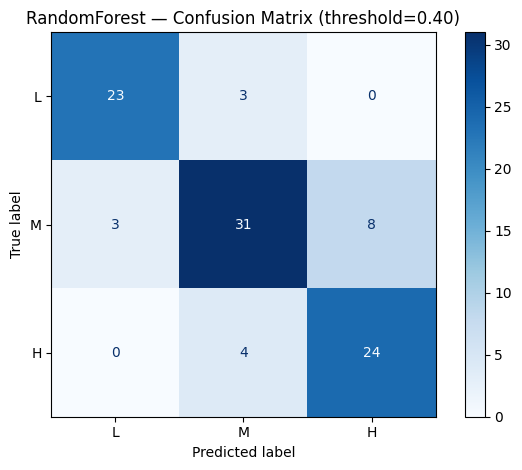

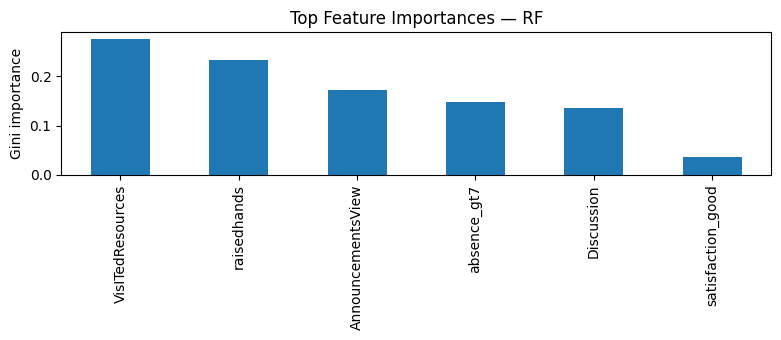

In [61]:
rfc = RandomForestClassifier(
    n_estimators=80,
    max_features='sqrt',
    max_depth=9,
    min_samples_leaf=1,
    min_samples_split=2,
    bootstrap=True,
    random_state=42
)

rfc.fit(X_train, y_train)

print("RF classes order:", rfc.classes_)

# Adjusting prediction for class H using a threshold
target_class = 2      # Class H
threshold = 0.40      # Adjusted threshold for class H

y_proba = rfc.predict_proba(X_test)

# Default prediction using argmax
y_pred = np.argmax(y_proba, axis=1)

# Set predictions to H for any student with P(H) >= threshold
mask = y_proba[:, target_class] >= threshold
y_pred[mask] = target_class

# Performance Report and Confusion Matrix
acc = accuracy_score(y_test, y_pred)
f1m = f1_score(y_test, y_pred, average="macro")

print("=== RandomForest Report (Test, threshold=0.40 for class H) ===")
print(f"Accuracy : {acc:.3f}")
print(f"F1_macro : {f1m:.3f}\n")

print(classification_report(
    y_test, y_pred,
    digits=3,
    zero_division=0,
    target_names=["L", "M", "H"]
))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    cmap="Blues",
    display_labels=["L", "M", "H"]
)
plt.title("RandomForest — Confusion Matrix (threshold=0.40)")
plt.tight_layout()
plt.show()

# Feature Importances
feature_names = X.columns.tolist()

importances = pd.Series(rfc.feature_importances_, index=feature_names)

ax = importances.sort_values(ascending=False).plot(
    kind='bar',
    figsize=(8, 3.5)
)
plt.title("Top Feature Importances — RF")
plt.ylabel("Gini importance")
plt.tight_layout()
plt.show()


In [62]:
import joblib
import os

# اسم المجلد كما يظهر في صورتك
save_folder = 'Saved_Models'

# التأكد من وجود المجلد (للاحتياط)
os.makedirs(save_folder, exist_ok=True)

# 1. تحديث ملف الموديل (سيستبدل الملف القديم بالجديد)
joblib.dump(rfc, os.path.join(save_folder, 'axi_rf_model.joblib'))

# 2. تحديث ملف السكيلر (مهم جداً تحدثه لأنك عدلت على البيانات أو التدريب)
joblib.dump(scaler, os.path.join(save_folder, 'axi_scaler.joblib'))

print("تم تحديث الموديل والسكيلر بنجاح! ✅")
print(f"تم الحفظ في المسار: {os.path.abspath(save_folder)}")

تم تحديث الموديل والسكيلر بنجاح! ✅
تم الحفظ في المسار: c:\Users\Syndictech\Downloads\AI model (2)\BAHAAW\AXI_Training\Saved_Models
